# Exploratory data analysis

The five findings that shaped this project's design. Each one is a decision
recorded in [`CLAUDE.md`](CLAUDE.md) §6, shown here as the evidence behind it.

**This notebook is presentation only.** It contains no project logic — it
imports the real modules rather than reimplementing them, so nothing here can
drift from what actually ships.

It runs against the **committed 600-game sample**, so a fresh clone can execute
it with no download. Where a figure differs meaningfully on the full 125,855-row
dataset, the full-dataset number is quoted in the text.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from recommender import clean, config, documents, load, popularity, schema, vectorize

plt.rcParams.update({"figure.figsize": (9, 3.6), "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})

SOURCE = config.SAMPLE_CSV  # swap for config.RAW_CSV to run on all 125,855 games
raw = load.load_raw(SOURCE)
print(f"{len(raw):,} rows loaded from {SOURCE.name}")

600 rows loaded from games_sample.csv


---
## 1. The header is malformed, and a naive read is silently wrong

The published CSV declares **39 column names** but every data row has **40
fields**. Header field 7 is `DiscountDLC count` — a missing comma between
`Discount` and `DLC count`. Everything from index 7 onward is therefore labelled
with its neighbour's name.

This is the single most important fact about the dataset. A misaligned read
still produces a structurally valid DataFrame, so it fails silently.

In [2]:
# Two plausible naive reads. Neither is correct, and neither raises.
default = pd.read_csv(SOURCE, low_memory=False)
no_index = pd.read_csv(SOURCE, index_col=False, low_memory=False)

fields = schema.PUBLISHED_HEADER_FIELD_COUNT + 1
print(f"header declares {default.shape[1]} columns, rows carry {fields} fields")

shown = ("AppID", "Name", "Release date", "About the game")
pd.DataFrame({
    "read_csv() default": [str(default[c].iloc[0])[:28] for c in shown],
    "index_col=False": [str(no_index[c].iloc[0])[:28] for c in shown],
    "actually holds": ["AppID", "Name", "Release date", "About the game"],
}, index=list(shown))

header declares 39 columns, rows carry 40 fields


,read_csv() default,index_col=False,actually holds
AppID,Apex Legends™,1172470,AppID
Name,"Nov 4, 2020",Apex Legends™,Name
Release date,100000000 - 200000000,"Nov 4, 2020",Release date
About the game,Conquer with character in Ap,0,About the game


In [3]:
# The default read silently promotes AppID to the *index*, shifting every
# column before the merged header field -- so "Name" holds release dates.
print(f"default read index: {list(default.index[:2])}  <- these are AppIDs")
print()

# index_col=False keeps 39 columns but shifts everything *after* the merge,
# so descriptions become DLC counts. That is the defect v1 shipped on.
naive_words = no_index["About the game"].dropna().astype(str).str.split().map(len)
true_words = raw["description"].astype(str).str.split().map(len)
naive_positive = pd.to_numeric(no_index["Positive"], errors="coerce").max()

print(f"mean description  -- index_col=False: {naive_words.mean():>10.1f} words")
print(f"                       via schema.py: {true_words.mean():>10.1f} words")
print()
print(f"max 'Positive'    -- index_col=False: {naive_positive:>10,.0f}   <- the User score field, 0 for most games")
print(f"                       via schema.py: {raw['positive'].max():>10,.0f}   <- real review counts")

default read index: [1172470, 294100]  <- these are AppIDs

mean description  -- index_col=False:        1.0 words
                       via schema.py:      266.6 words

max 'Positive'    -- index_col=False:          0   <- the User score field, 0 for most games
                       via schema.py:  7,642,084   <- real review counts


A first version of this project shipped on the misaligned read. Its TF-IDF index
was built from *Categories + Publishers + Genres* — no tags, no descriptions — so
it was a **publisher matcher** that looked plausible because it silently grouped
games by publisher.

`recommender/schema.py` supplies the true 40-field layout positionally, and
`tests/test_load.py` asserts on column **contents** rather than shape.

---
## 2. `Estimated owners` cannot rank anything

The obvious popularity signal turns out to be useless: it is a coarse bucket,
and most of the catalogue sits in the smallest one.

14 distinct buckets; largest holds 32% of rows (full dataset: 14 buckets, 60%)



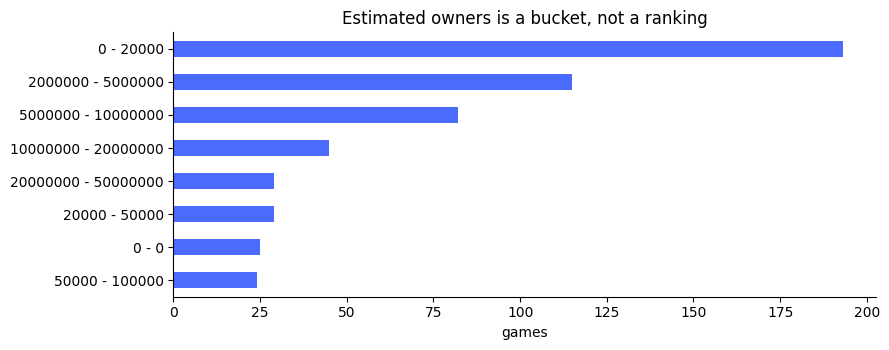

In [4]:
buckets = raw["estimated_owners"].value_counts()
share = buckets.iloc[0] / len(raw)
print(f"{len(buckets)} distinct buckets; largest holds {share:.0%} of rows "
      f"(full dataset: 14 buckets, 60%)\n")

ax = buckets.head(8).sort_values().plot.barh(color="#4b6bff")
ax.set(xlabel="games", ylabel="", title="Estimated owners is a bucket, not a ranking")
plt.tight_layout()

It is kept for display and filtering only. Ranking uses the Wilson score
instead — see §4 below.

---
## 3. The review threshold is a *tag-coverage* filter, not a popularity filter

The catalogue keeps games with `reviews >= 10`, which sounds like it discards
unpopular games. It does not — it discards **unrecommendable** ones. Games with
no reviews have essentially no tags, so there is nothing to recommend them on.

,tag coverage
0,0.0%
1-9,nan%
10-99,100.0%
100-999,100.0%
1000+,100.0%


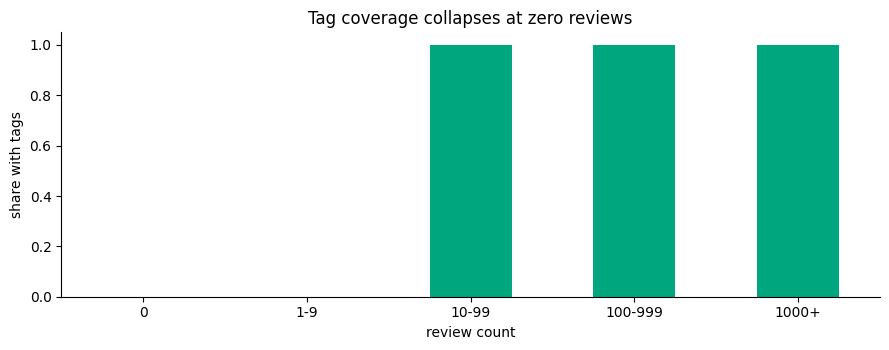

In [5]:
reviews = raw["positive"] + raw["negative"]
has_tags = raw["tags"].str.strip() != ""

bands = pd.cut(reviews, [-1, 0, 9, 99, 999, 10**9],
               labels=["0", "1-9", "10-99", "100-999", "1000+"])
coverage = has_tags.groupby(bands, observed=False).mean()

ax = coverage.plot.bar(color=["#d64545" if v < 0.5 else "#00a67e" for v in coverage])
ax.set(xlabel="review count", ylabel="share with tags", ylim=(0, 1.05),
       title="Tag coverage collapses at zero reviews")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()

coverage.map(lambda v: f"{v:.1%}").to_frame("tag coverage")

In [6]:
games = clean.clean(raw)
kept = len(games) / len(raw)
print(f"kept {len(games):,} of {len(raw):,} rows ({kept:.1%})")
print("full dataset: 55,973 of 125,855 (44.5%)\n")
print("(the sample deliberately over-weights famous games, so its median "
      "review count is far above the full catalogue's 60)")
print(f"after cleaning -- tag coverage {(games['tags'].map(len) > 0).mean():.1%}, "
      f"median reviews {games['total_reviews'].median():.0f}")

kept 539 of 600 rows (89.8%)
full dataset: 55,973 of 125,855 (44.5%)

(the sample deliberately over-weights famous games, so its median review count is far above the full catalogue's 60)
after cleaning -- tag coverage 100.0%, median reviews 83448


---
## 4. Wilson beats the raw positive ratio

Steam reviews are **binary up/down votes**, so the right estimator is the Wilson
score interval lower bound — not a star-rating formula like IMDb's weighted
rating, which assumes a continuous scale and an arbitrary prior mean.

Sorting by raw ratio returns games with a handful of reviews sitting at 100%.

In [7]:
scored = games.assign(
    ratio=games["positive"] / games["total_reviews"],
    wilson=popularity.wilson_lower_bound(games["positive"], games["negative"]),
)

def top(by):
    out = scored.nlargest(5, by)[["name", "total_reviews", by]]
    return out.assign(name=out["name"].str[:28]).reset_index(drop=True)

print("TOP 5 BY RAW POSITIVE RATIO")
display(top("ratio"))
print("\nTOP 5 BY WILSON LOWER BOUND")
display(top("wilson"))

TOP 5 BY RAW POSITIVE RATIO


,name,total_reviews,ratio
0,Animal Rivals: Up In The Air,11,1.0
1,Beep's Escape,28,1.0
2,祛魅·化始（祛魅4）,19,1.0
3,Beef Cat Ultra,12,1.0
4,Vesper: Ether Saga - Episode,10,1.0



TOP 5 BY WILSON LOWER BOUND


,name,total_reviews,wilson
0,Portal 2,433510,0.986566
1,People Playground,281763,0.985299
2,Stardew Valley,886195,0.984155
3,Portal,177741,0.984133
4,Vampire Survivors,250334,0.984111


,name,total_reviews,wilson,popularity
0,Black Myth: Wukong,1150098,0.966301,0.905514
1,Schedule I,204041,0.983579,0.892849
2,Baldur's Gate 3,760662,0.968088,0.885105
3,Lethal Company,487160,0.971331,0.881332
4,Satisfactory,232064,0.970941,0.879168
5,R.E.P.O.,185642,0.964206,0.878256
6,MiSide,111087,0.979323,0.874219
7,Split Fiction,81558,0.974243,0.869215


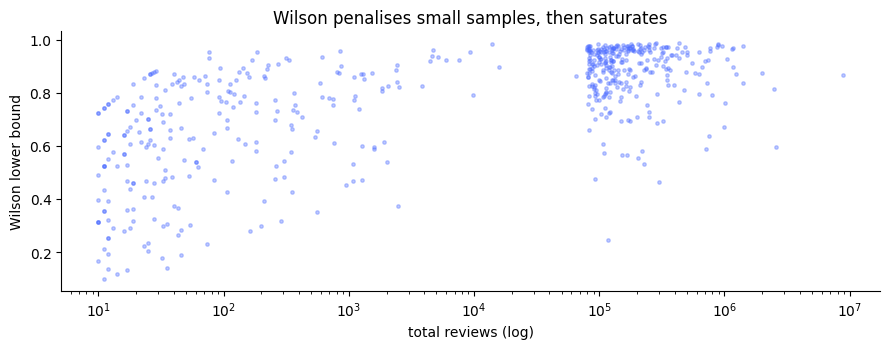

In [8]:
# Wilson saturates above ~10k reviews, so reach and recency are blended in.
scored = scored.assign(popularity=popularity.popularity_score(games))

ax = scored.plot.scatter(x="total_reviews", y="wilson", s=6, alpha=0.35, color="#4b6bff")
ax.set(xscale="log", xlabel="total reviews (log)", ylabel="Wilson lower bound",
       title="Wilson penalises small samples, then saturates")
plt.tight_layout()

scored.nlargest(8, "popularity")[["name", "total_reviews", "wilson", "popularity"]] \
      .reset_index(drop=True)

---
## 5. Why three TF-IDF spaces, not one document

The three field groups have wildly different vocabulary sizes. Concatenated into
one document, description prose dominates the vocabulary and distorts IDF for
the 449 curated tags — which are the most precise signal available.

In [9]:
matrices = vectorize.fit(documents.build_documents(games))

sizes = pd.Series({name: m.shape[1] for name, m in matrices.items()}, name="terms")
print(sizes.to_string(), "\n")
print("full dataset: tags 449, genres 86, description 30,000")
print("\nmeasured NDCG@10 -- three weighted spaces 0.259 vs one concatenated 0.169 (+53%)")

tags             385
genres            76
description    13147 

full dataset: tags 449, genres 86, description 30,000

measured NDCG@10 -- three weighted spaces 0.259 vs one concatenated 0.169 (+53%)


385 distinct tags; rarest are the informative ones, which is what explanations rank by


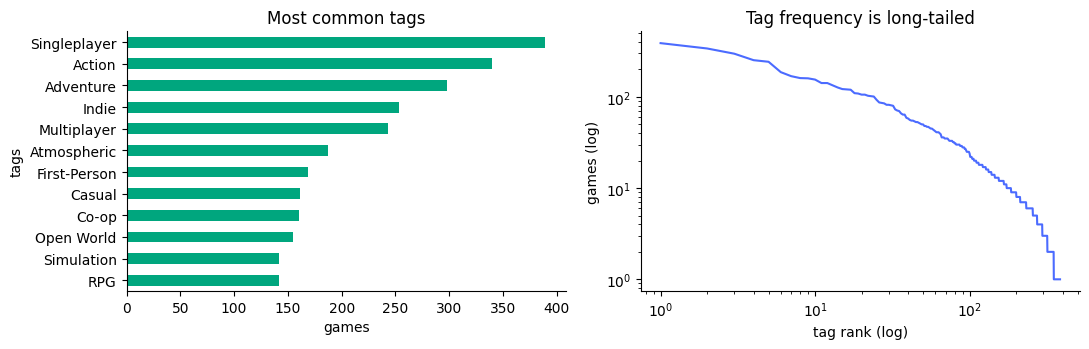

In [10]:
tag_counts = games["tags"].explode().value_counts()

fig, (left, right) = plt.subplots(1, 2, figsize=(11, 3.6))
tag_counts.head(12).sort_values().plot.barh(ax=left, color="#00a67e")
left.set(xlabel="games", title="Most common tags")

right.plot(range(1, len(tag_counts) + 1), tag_counts.to_numpy(), color="#4b6bff")
right.set(xscale="log", yscale="log", xlabel="tag rank (log)", ylabel="games (log)",
          title="Tag frequency is long-tailed")
plt.tight_layout()

print(f"{len(tag_counts)} distinct tags; rarest are the informative ones, "
      "which is what explanations rank by")

---
## Takeaways

| finding | decision it drove |
|---|---|
| Header declares 39 columns, rows have 40 | A tested column contract in `schema.py` (§6.1) |
| `Estimated owners` is 14 coarse buckets | Display and filtering only; never ranking (§6.2) |
| Tag coverage is 0.9% at zero reviews, 100% above | `MIN_REVIEWS = 10` as a coverage filter (§6.3) |
| Reviews are binary votes | Wilson lower bound, not a star-rating formula (§6.2) |
| 449 tags vs 30,000 description terms | Three separate TF-IDF spaces (§6.4) |
| Rare shared tags carry the most information | Explanations rank shared tags by rarity (§6.8) |

Full reasoning for every decision — including the two that measurement
reversed — is in [`CLAUDE.md`](CLAUDE.md). Ranking results are in
[`evaluation/results.md`](evaluation/results.md).